# Initial EDA

**Project:** Power Consumption MLOps (Tetouan City)  
**Goal:** Validate dataset usability and update the data contract (schema, cadence, missingness, ranges) before building pipeline code.  
**Output:** `docs/01-eda-findings.md` (summary) + confirmed schema/types for `docs/00-problem-statement.md` (v1).

> This notebook is intentionally short and operational. No heavy plotting or modeling.



## 1) Setup & Config

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# assumes this notebook lives in: <repo>/notebooks/
REPO_ROOT = Path.cwd().parents[0]
DATA_PATH = REPO_ROOT / "data" / "raw" / "tetouan-power-consumption.csv"

assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"
DATA_PATH

WindowsPath('c:/Users/lcbae/Desktop/databricks-repo/power-consumption-mlops/data/raw/tetouan-power-consumption.csv')

In [2]:
# Adjust pandas display options to avoid column truncation during EDA
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## 2) Load Data

We load the raw CSV as-is (no cleaning yet). This step validates encoding, delimiters, and column names.

In [3]:
df = pd.read_csv(DATA_PATH)
df.shape

(52416, 9)

In [4]:
df.head(3)

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373


## 3) Column Overview

We verify:
- Column names (exact spelling)
- Initial inferred dtypes
- Whether the expected targets exist (Zone 1/2/3)

In [5]:
df.columns.tolist()

['DateTime',
 'Temperature',
 'Humidity',
 'Wind Speed',
 'general diffuse flows',
 'diffuse flows',
 'Zone 1 Power Consumption',
 'Zone 2  Power Consumption',
 'Zone 3  Power Consumption']

In [6]:
df.dtypes

DateTime                         str
Temperature                  float64
Humidity                     float64
Wind Speed                   float64
general diffuse flows        float64
diffuse flows                float64
Zone 1 Power Consumption     float64
Zone 2  Power Consumption    float64
Zone 3  Power Consumption    float64
dtype: object

In [7]:
df.describe(include="all").T.head(10)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DateTime,52416,52416,1/1/2017 0:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,52416.0,NaN,NaN,NaN,18.810024,5.815476,3.247,14.41,18.78,22.89,40.01
Humidity,52416.0,NaN,NaN,NaN,68.259518,15.551177,11.34,58.31,69.86,81.4,94.8
Wind Speed,52416.0,NaN,NaN,NaN,1.959489,2.348862,0.05,0.078,0.086,4.915,6.483
general diffuse flows,52416.0,NaN,NaN,NaN,182.696614,264.40096,0.004,0.062,5.0355,319.6,1163.0
diffuse flows,52416.0,NaN,NaN,NaN,75.028022,124.210949,0.011,0.122,4.456,101.0,936.0
Zone 1 Power Consumption,52416.0,NaN,NaN,NaN,32344.970564,7130.562564,13895.6962,26310.668692,32265.92034,37309.018185,52204.39512
Zone 2 Power Consumption,52416.0,NaN,NaN,NaN,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.71752,37408.86076
Zone 3 Power Consumption,52416.0,NaN,NaN,NaN,17835.406218,6622.165099,5935.17407,13129.32663,16415.11747,21624.10042,47598.32636


## 4) Basic Quality Checks

We check:
- missing values
- duplicates
- obvious invalid values (e.g., negatives for consumption)

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

DateTime                     0
Temperature                  0
Humidity                     0
Wind Speed                   0
general diffuse flows        0
diffuse flows                0
Zone 1 Power Consumption     0
Zone 2  Power Consumption    0
Zone 3  Power Consumption    0
dtype: int64

In [9]:
dup_rows = df.duplicated().sum()
dup_rows

np.int64(0)

In [10]:
df[df.duplicated(keep=False)]

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption


## 5) Identify Timestamps & Targets

We locate the datetime column and the target column(s).  
Then we normalize names for later pipeline use (snake_case).

In [11]:
# All columns
df.columns.tolist()

['DateTime',
 'Temperature',
 'Humidity',
 'Wind Speed',
 'general diffuse flows',
 'diffuse flows',
 'Zone 1 Power Consumption',
 'Zone 2  Power Consumption',
 'Zone 3  Power Consumption']

In [12]:
# Heuristic search for datetime-like column names
[c for c in df.columns if "date" in c.lower() or "time" in c.lower()]

['DateTime']

In [13]:
# Heuristic search for zone targets
[c for c in df.columns if "zone" in c.lower()]

['Zone 1 Power Consumption',
 'Zone 2  Power Consumption',
 'Zone 3  Power Consumption']

In [14]:
# Renaming columns
rename_cols = {
    "DateTime": "datetime",
    "Temperature": "temperature_c",
    "Humidity": "humidity_pct",
    "Wind Speed": "wind_speed_m_s",
    "general diffuse flows": "diffuse_flows_kwh",
    "diffuse flows": "diffuse_flows_kwh",
    "Zone 1 Power Consumption": "zone1_consumption_kw",
    "Zone 2  Power Consumption": "zone2_consumption_kw",
    "Zone 3  Power Consumption": "zone3_consumption_kw",
}
df.rename(columns=rename_cols, inplace=True)
df.columns.tolist()

['datetime',
 'temperature_c',
 'humidity_pct',
 'wind_speed_m_s',
 'diffuse_flows_kwh',
 'diffuse_flows_kwh',
 'zone1_consumption_kw',
 'zone2_consumption_kw',
 'zone3_consumption_kw']

In [15]:
TIME_COL = "datetime"
FEATURES = [
    "temperature_c",
    "humidity_pct",
    "wind_speed_m_s",
    "diffuse_flows_kwh",
]
TARGET_COLS = [
    "zone1_consumption_kw",
    "zone2_consumption_kw",
    "zone3_consumption_kw",
]

# Assert that the required columns exist
assert TIME_COL in df.columns, f"{TIME_COL=} not found"

for c in FEATURES:
    assert c in df.columns, f"Feature column missing: {c}"

for c in TARGET_COLS:
    assert c in df.columns, f"Target column missing: {c}"

TIME_COL, FEATURES, TARGET_COLS

('datetime',
 ['temperature_c', 'humidity_pct', 'wind_speed_m_s', 'diffuse_flows_kwh'],
 ['zone1_consumption_kw', 'zone2_consumption_kw', 'zone3_consumption_kw'])

## 6) Parse Datetime
We parse the time column, check parse failures, sort by time, and inspect min/max timestamps.

> *Parse:* Convert string to datetime 

In [16]:
df.dtypes

datetime                    str
temperature_c           float64
humidity_pct            float64
wind_speed_m_s          float64
diffuse_flows_kwh       float64
diffuse_flows_kwh       float64
zone1_consumption_kw    float64
zone2_consumption_kw    float64
zone3_consumption_kw    float64
dtype: object

In [23]:
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

# Number of parse failures
n_bad = df[TIME_COL].isna().sum()
n_bad

np.int64(0)

In [18]:
df.dtypes

datetime                datetime64[us]
temperature_c                  float64
humidity_pct                   float64
wind_speed_m_s                 float64
diffuse_flows_kwh              float64
diffuse_flows_kwh              float64
zone1_consumption_kw           float64
zone2_consumption_kw           float64
zone3_consumption_kw           float64
dtype: object

In [25]:
# If parsing failures exist, inspect examples
if n_bad > 0:
    df[df[TIME_COL].isna()]

In [33]:
df = df.sort_values(TIME_COL).reset_index(drop=True)

print(f"min: {df[TIME_COL].min()}, max: {df[TIME_COL].max()} \n")

print("First 3 timestamps")
display(df[[TIME_COL]].head(3))

print("Last 3 timestamps")
display(df[[TIME_COL]].tail(3))

min: 2017-01-01 00:00:00, max: 2017-12-30 23:50:00 

First 3 timestamps


,datetime
0,2017-01-01 00:00:00
1,2017-01-01 00:10:00
2,2017-01-01 00:20:00


Last 3 timestamps


,datetime
52413,2017-12-30 23:30:00
52414,2017-12-30 23:40:00
52415,2017-12-30 23:50:00


## 7) Confirm Cadence & Gaps

For time series, split strategy and feature engineering depend on true cadence.
We compute the distribution of time deltas and detect missing intervals.

In [35]:
# Compute time deltas between consecutive timestamps
deltas = df[TIME_COL].diff().dropna()

# Count occurrences of each delta value
deltas.value_counts().head(10)

datetime
0 days 00:10:00    52415
Name: count, dtype: int64

In [36]:
# Most common delta (expected cadence)
mode_delta = deltas.mode().iloc[0]
mode_delta

Timedelta('0 days 00:10:00')

## 8) Target Sanity

We validate targets:
- no negatives
- range looks plausible
- check for extreme outliers

In [39]:
target_summary = df[TARGET_COLS].describe().T
target_summary

,count,mean,std,min,25%,50%,75%,max
zone1_consumption_kw,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
zone2_consumption_kw,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
zone3_consumption_kw,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636


In [40]:
(df[TARGET_COLS] < 0).sum()

zone1_consumption_kw    0
zone2_consumption_kw    0
zone3_consumption_kw    0
dtype: int64

## 9) Feature Sanity


In [44]:
feat_summary = df[FEATURES].describe().T
feat_summary

,count,mean,std,min,25%,50%,75%,max
temperature_c,52416.0,18.810024,5.815476,3.247,14.410,18.7800,22.890,40.010
humidity_pct,52416.0,68.259518,15.551177,11.340,58.310,69.8600,81.400,94.800
wind_speed_m_s,52416.0,1.959489,2.348862,0.050,0.078,0.0860,4.915,6.483
diffuse_flows_kwh,52416.0,182.696614,264.400960,0.004,0.062,5.0355,319.600,1163.000
diffuse_flows_kwh,52416.0,75.028022,124.210949,0.011,0.122,4.4560,101.000,936.000


## 10) Correlation

We compute correlations between numeric features and Zone 1 consumption.
This is only a sanity check (not modeling).

In [49]:
zone1 = TARGET_COLS[0]
corr_matrix = df[FEATURES + [zone1]].corr()
corr_matrix

,temperature_c,humidity_pct,wind_speed_m_s,diffuse_flows_kwh,diffuse_flows_kwh,zone1_consumption_kw
temperature_c,1.000000,-0.460243,0.477109,0.460294,0.196522,0.440221
humidity_pct,-0.460243,1.000000,-0.135853,-0.468138,-0.256886,-0.287421
wind_speed_m_s,0.477109,-0.135853,1.000000,0.133733,-0.000972,0.167444
diffuse_flows_kwh,0.460294,-0.468138,0.133733,1.000000,0.564718,0.187965
diffuse_flows_kwh,0.196522,-0.256886,-0.000972,0.564718,1.000000,0.080274
zone1_consumption_kw,0.440221,-0.287421,0.167444,0.187965,0.080274,1.000000


## 11) Data Contract

We generate a table of:
- column name
- dtype
- nullable
This becomes the basis of `docs/01-eda-findings.md` and updates `docs/00-problem-statement.md` (v1).

In [52]:
contract = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "nullable": df.isna().any().values,
    "n_missing": df.isna().sum().values,
})
contract.sort_values(["nullable", "n_missing"], ascending=[False, False])

,column,dtype,nullable,n_missing
0,datetime,datetime64[us],False,0
1,temperature_c,float64,False,0
2,humidity_pct,float64,False,0
3,wind_speed_m_s,float64,False,0
4,diffuse_flows_kwh,float64,False,0
5,diffuse_flows_kwh,float64,False,0
6,zone1_consumption_kw,float64,False,0
7,zone2_consumption_kw,float64,False,0
8,zone3_consumption_kw,float64,False,0


## 12) EDA Findings Summary

Copy these bullets into `docs/01-eda-findings.md`:
- Rows:
- Columns:
- Time range:
- Cadence (mode delta):
- Missing values:
- Duplicate rows:
- Gaps detected:
- Targets:
  - any negatives?
  - max values (approx):
- Notes/risks:
- Decisions for v1:
  - target chosen:
  - split strategy:
  - horizon:

In [54]:
summary = {
    "rows": int(df.shape[0]),
    "cols": int(df.shape[1]),
    "time_min": str(df[TIME_COL].min()),
    "time_max": str(df[TIME_COL].max()),
    "mode_delta": str(mode_delta),
    "n_missing_total": int(df.isna().sum().sum()),
    "dup_rows": int(dup_rows),
    "any_negative_targets": bool((df[TARGET_COLS] < 0).any().any()),
}

summary

{'rows': 52416,
 'cols': 9,
 'time_min': '2017-01-01 00:00:00',
 'time_max': '2017-12-30 23:50:00',
 'mode_delta': '0 days 00:10:00',
 'n_missing_total': 0,
 'dup_rows': 0,
 'any_negative_targets': False}

## 14) Time-Series Plots


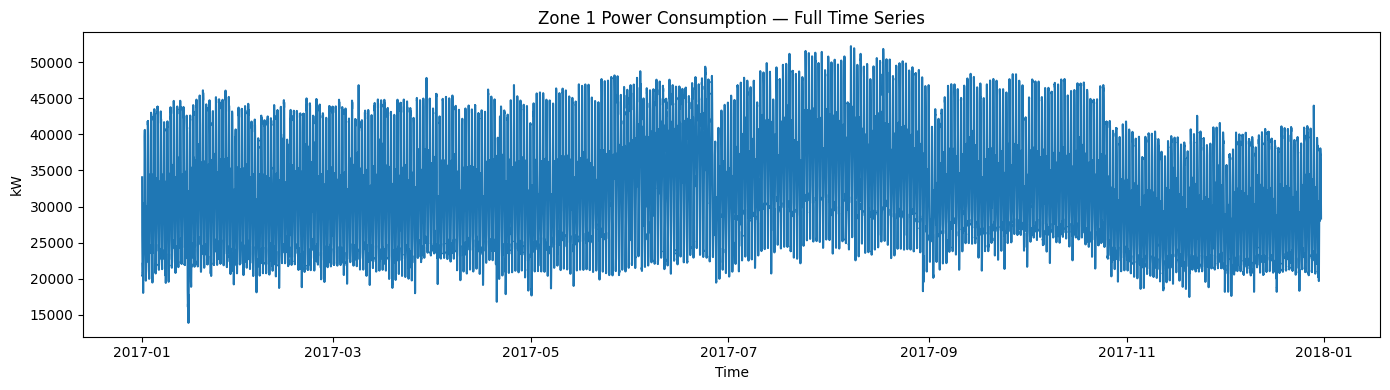

In [62]:
# Full time-series
plt.figure(figsize=(14,4))
plt.plot(df[TIME_COL], df[TARGET_COLS[0]])
plt.title("Zone 1 Power Consumption — Full Time Series")
plt.xlabel("Time")
plt.ylabel("kW")
plt.tight_layout()
plt.show()

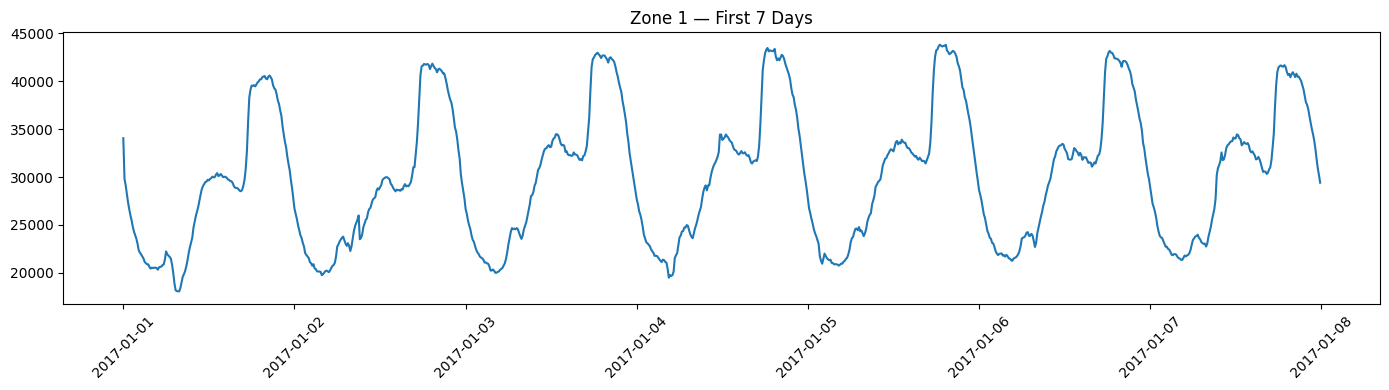

In [63]:
# Zoom in on first 7 days
window = df.iloc[:7*24*6]  # if 10-min data (~6 per hour)

plt.figure(figsize=(14,4))
plt.plot(window[TIME_COL], window[TARGET_COLS[0]])
plt.title("Zone 1 — First 7 Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

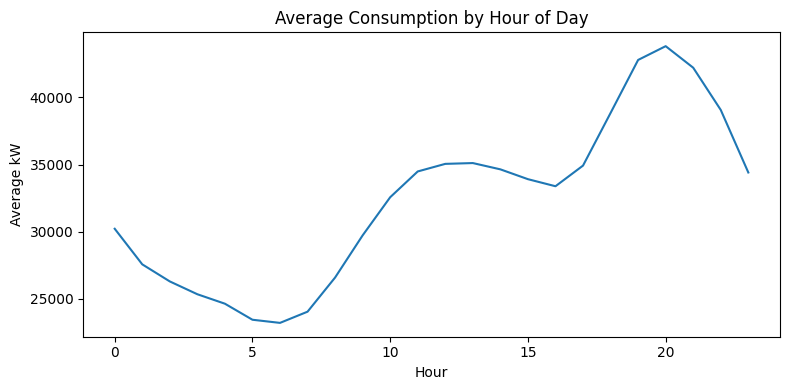

In [64]:
# Daily seasonality
df["hour"] = df[TIME_COL].dt.hour

hourly_mean = df.groupby("hour")[TARGET_COLS[0]].mean()

plt.figure(figsize=(8,4))
plt.plot(hourly_mean.index, hourly_mean.values)
plt.title("Average Consumption by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average kW")
plt.tight_layout()
plt.show()

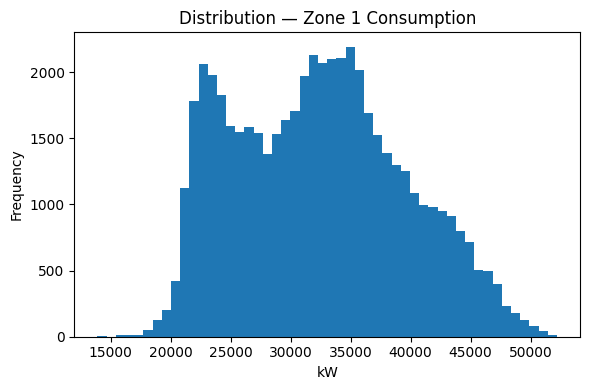

In [65]:
# Distribution Plot
plt.figure(figsize=(6,4))
plt.hist(df[TARGET_COLS[0]], bins=50)
plt.title("Distribution — Zone 1 Consumption")
plt.xlabel("kW")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 12) Key Plot Insights (What We Learned)

### 1) Full time series (year view)
**Observations**
- Strong seasonality across the year.
- Higher consumption mid-year (summer), lower toward year-end.
- No obvious structural breaks or prolonged flatlines.
- No catastrophic outliers.

**Conclusion**
- The series is stable and learnable; no special regime-shift handling is required at this stage.

---

### 2) First 7 days (zoom)
**Observations**
- Smooth intra-day cycles with consistent behavior.
- High-resolution sampling appears consistent with a ~10-minute cadence.
- Signal-to-noise ratio is good (not extremely noisy).

**Conclusion**
- A classical ML baseline with time features should work well.
- No heavy smoothing or aggressive filtering is needed initially.

---

### 3) Hour-of-day pattern (most important)
**Observations**
- Clear daily structure.
- Minimum around ~05:00–06:00.
- Peak around ~19:00–20:00.
- Non-linear relationship between hour-of-day and consumption.

**Conclusion**
- Time features are mandatory. Include cyclical encodings:
  - `sin(hour)`, `cos(hour)`
- Also consider:
  - day-of-week
  - month / seasonal encoding

---

### 4) Target distribution
**Observations**
- Slight right skew, but no extreme long-tail behavior.
- No negative values.
- No strong bimodality.

**Conclusion**
- MAE is a good primary metric.
- No log-transform is required for the baseline.
- Linear models could perform reasonably as an initial benchmark.

---

## Final EDA Assessment

**Validated facts**
- Cadence: consistent, ~10-minute intervals.
- Time range: full-year coverage of 2017 (ends on Dec 30).
- Strong daily + seasonal patterns.
- No major data-quality red flags (missingness/duplicates/outliers are not problematic).

**Implication**
- This is a clean dataset suitable for an end-to-end forecasting pipeline.

---

## Architectural Decision: 10-minute vs hourly

Because cadence is ~10 minutes, we must choose the modeling resolution.

### Option A — Keep 10-minute resolution
**Pros**
- More samples (~52k rows)
- More granular forecasts

**Cons**
- Slightly higher feature engineering complexity (lags/rolling windows)
- Potentially more noise sensitivity (still manageable here)

### Option B — Aggregate to hourly
**Pros**
- Simpler modeling and faster iteration
- Aligns with many operational planning workflows

**Cons**
- Loss of granularity (may smooth peaks/troughs)

**Decision (for now)**
- Start with **10-minute** resolution for baseline, but keep aggregation as a **configurable option** later.

---

## Next Actions

1) Update `docs/00-problem-statement.md` → **Version 1** with:
- confirmed cadence
- confirmed time range
- confirmed “no major gaps”
- initial split strategy

2) Choose a time-based split strategy.
Recommended for this dataset:
- **Train:** Jan–Sep 2017  
- **Validation:** Oct–Nov 2017  
- **Test:** Dec 2017 (through Dec 30)

This preserves seasonality and prevents leakage from random splits.